## Matplotlib Subplot 
    A Matplotlib subplot is a way to display multiple plots in a single figure, arranged in a grid of rows and columns. It helps compare graphs side-by-side or show related visualizations together.
    A subplot divides one figure into smaller plotting areas called axes. Each axis behaves like an independent plot but shares the same canvas.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random
from matplotlib import style

C:\Users\HP\AppData\Local\Temp\ipykernel_12364\2981067288.py:150: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
C:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


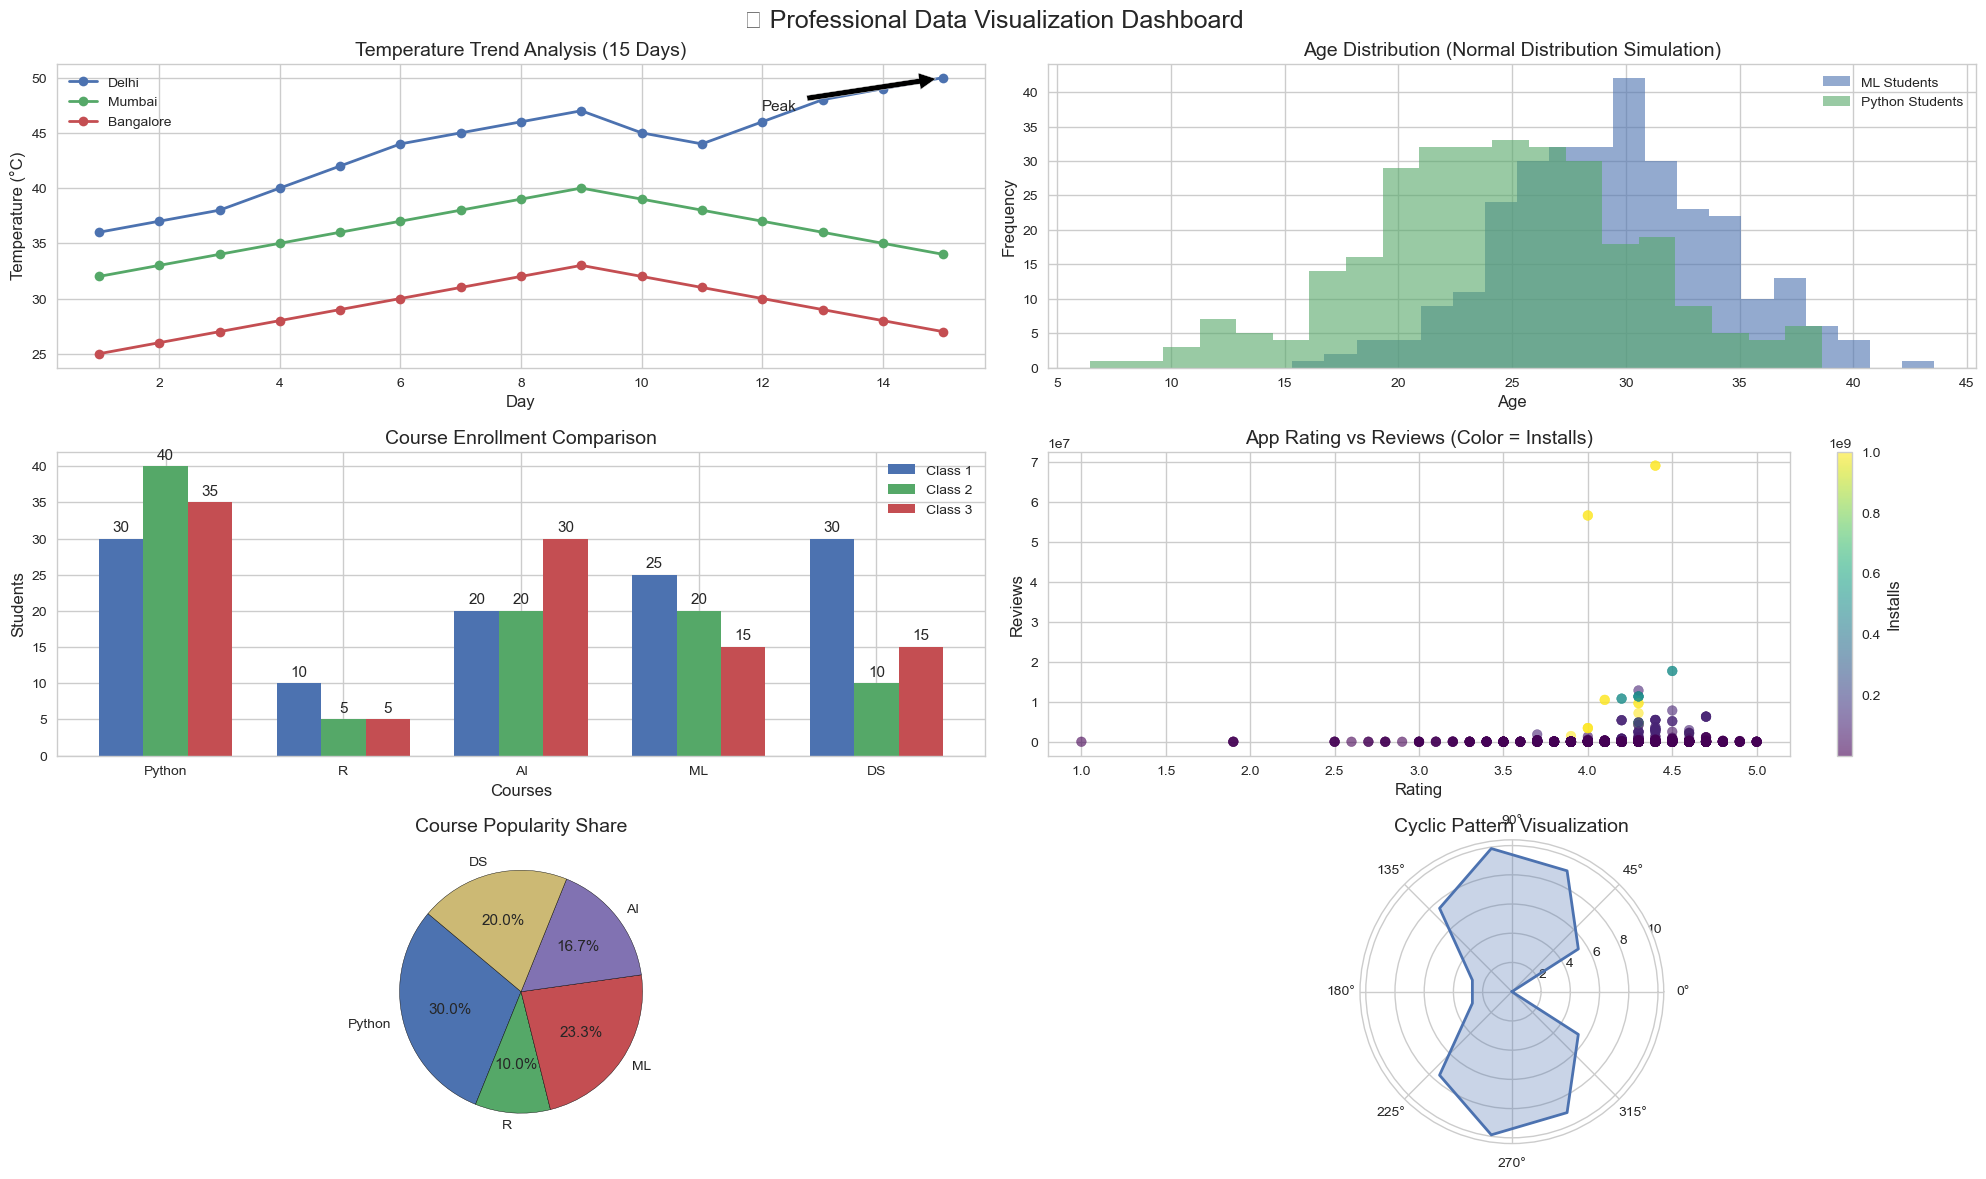

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ==========================================================
# GLOBAL STYLE CONFIG (Professional Look)
# ==========================================================
plt.style.use("seaborn-v0_8-whitegrid")

plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "legend.fontsize": 10
})

fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 2)

# ==========================================================
# CHART 1: MULTI-LINE TREND ANALYSIS
# ==========================================================
ax1 = fig.add_subplot(gs[0, 0])

days = np.arange(1, 16)

cities = {
    "Delhi": [36,37,38,40,42,44,45,46,47,45,44,46,48,49,50],
    "Mumbai": [32,33,34,35,36,37,38,39,40,39,38,37,36,35,34],
    "Bangalore": [25,26,27,28,29,30,31,32,33,32,31,30,29,28,27]
}

for city, temp in cities.items():
    ax1.plot(days, temp, marker='o', linewidth=2, label=city)

ax1.set_title("Temperature Trend Analysis (15 Days)")
ax1.set_xlabel("Day")
ax1.set_ylabel("Temperature (°C)")
ax1.legend()
ax1.annotate("Peak", xy=(15,50), xytext=(12,47),
             arrowprops=dict(facecolor='black', shrink=0.05))

# ==========================================================
# CHART 2: HISTOGRAM + KDE STYLE LOOK
# ==========================================================
ax2 = fig.add_subplot(gs[0, 1])

ml_age = np.random.normal(30, 5, 300)
py_age = np.random.normal(25, 6, 300)

ax2.hist(ml_age, bins=20, alpha=0.6, label="ML Students")
ax2.hist(py_age, bins=20, alpha=0.6, label="Python Students")

ax2.set_title("Age Distribution (Normal Distribution Simulation)")
ax2.set_xlabel("Age")
ax2.set_ylabel("Frequency")
ax2.legend()

# ==========================================================
# CHART 3: GROUPED BAR (COMPARATIVE ANALYSIS)
# ==========================================================
ax3 = fig.add_subplot(gs[1, 0])

courses = ["Python", "R", "AI", "ML", "DS"]

class1 = np.array([30, 10, 20, 25, 30])
class2 = np.array([40, 5, 20, 20, 10])
class3 = np.array([35, 5, 30, 15, 15])

x = np.arange(len(courses))
width = 0.25

bars1 = ax3.bar(x - width, class1, width, label="Class 1")
bars2 = ax3.bar(x, class2, width, label="Class 2")
bars3 = ax3.bar(x + width, class3, width, label="Class 3")

# Add labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2, height + 1,
                 f'{int(height)}', ha='center')

ax3.set_xticks(x)
ax3.set_xticklabels(courses)
ax3.set_title("Course Enrollment Comparison")
ax3.set_xlabel("Courses")
ax3.set_ylabel("Students")
ax3.legend()

# ==========================================================
# CHART 4: SCATTER (REAL DATA ANALYSIS)
# ==========================================================
ax4 = fig.add_subplot(gs[1, 1])

df = pd.read_csv("googleplaystore.csv", nrows=1000)

df = df.dropna(subset=["Rating", "Reviews", "Installs"])
df["Installs"] = df["Installs"].str.replace('[+,]', '', regex=True).astype(float)

sc = ax4.scatter(
    df["Rating"],
    df["Reviews"],
    c=df["Installs"],
    cmap="viridis",
    alpha=0.6
)

plt.colorbar(sc, ax=ax4, label="Installs")

ax4.set_title("App Rating vs Reviews (Color = Installs)")
ax4.set_xlabel("Rating")
ax4.set_ylabel("Reviews")

# ==========================================================
# CHART 5: PIE (MINIMALISTIC STYLE)
# ==========================================================
ax5 = fig.add_subplot(gs[2, 0])

labels = ["Python", "R", "ML", "AI", "DS"]
sizes = [45, 15, 35, 25, 30]

ax5.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops={'edgecolor': 'black'}
)

ax5.set_title("Course Popularity Share")

# ==========================================================
# CHART 6: POLAR (ADVANCED VISUALIZATION)
# ==========================================================
ax6 = fig.add_subplot(gs[2, 1], projection='polar')

theta = np.linspace(0, 2*np.pi, 12)
r = np.abs(np.sin(theta) * 10)

ax6.plot(theta, r, linewidth=2)
ax6.fill(theta, r, alpha=0.3)

ax6.set_title("Cyclic Pattern Visualization")

# ==========================================================
# FINAL TOUCH
# ==========================================================
fig.suptitle("📊 Professional Data Visualization Dashboard", fontsize=18)
plt.tight_layout()
plt.show()